## Βαθιά Μάθηση : Εργασία 2025-2026

#### Δημήτριος Μουταφτσίδης , 9920
#### moutdimi@ece.atuh.gr

In [10]:
#Basic libraries we need for different operations.
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time
import os
import glob
import copy
import pickle

#Basic torch modules, including transformations, dataloaders etc.
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms , models

#Importing the Neural Network modules as well as the optimizer.
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

#Sickit-Learn offers very neat performance metrics.
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score

#Importing the libraries containing the dataset. 
import medmnist
from medmnist import INFO
from medmnist import PneumoniaMNIST

#Vision Transformer.
import timm

### 1. Συναρτήσεις.
Για ακόμα μία φορά ο κώδικας χρησιμοποιείται αυτούσιος. Μοναδική εξαίρεση είναι μία τροποποίηση στην συνάρτηση Train_classifier. Πλέον, όταν εκπαιδεύουμε μόνο classifier head θέτουμε το frozen backbone σε evaluation mode. Έτσι αποτρέπουμε διεργασίες όπως το dropout από το να είναι ενεργές. Το να το αφήναμε σε training mode θα εισήγαγε θόρυβο στον οποίο ο feature extractor δεν θα μπορούσε να προσαρμοστεί λόγω του "παγώματος". Το σχετικό section είναι σχολιασμένο.

In [3]:
def Train_Classifier(model, initial_lr , weight_decay , num_epochs , training_dataloader, validation_dataloader , use_scheduler = False , weight = None):

    criterion = nn.CrossEntropyLoss(weight = weight)

    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_parameters, lr = initial_lr , weight_decay = weight_decay)

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode = "min",
            factor = 0.5,
            patience = 2,
            threshold = 1e-3,
            threshold_mode = "abs",
            cooldown = 1,
            min_lr = 1e-6
        )
    else:
        scheduler = None

    with_accuracy = None
    at_epoch = None
    best_validation_loss = float("inf")
    best_validation_accuracy = 0.0
    best_state = None
    best_epoch = None

    training_accuracies = []
    validation_accuracies = []
    training_losses = []
    validation_losses = []

    start = time.time()

    for epoch in range(1, num_epochs + 1):

        #Set the frozen backbone to evaluation mode if head-only training is selected.
        if all(not p.requires_grad for name, p in model.named_parameters() if not name.startswith("head")):
            model.eval()
            #Set only the head to training mode.
            if hasattr(model, "head") and model.head is not None:
                model.head.train()
            #Include safeguard for distilation head if present. We know that our model doesn't have one.
            if hasattr(model, "head_dist") and model.head_dist is not None:
                model.head_dist.train()
        #If not in head-only mode, set model to evaluation to allow for training of the unfrozen layers.
        else:
            model.train()

        correct = 0
        total = 0
        running_loss = 0.0

        for images, labels in training_dataloader:
            labels = labels.squeeze(1).long()
            optimizer.zero_grad()
            scores = model(images)
            loss = criterion(scores, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            predictions = scores.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        epoch_training_loss = running_loss / len(training_dataloader.dataset)
        epoch_training_accuracy = correct / total
        training_losses.append(epoch_training_loss)
        training_accuracies.append(epoch_training_accuracy)

        model.eval()
        correct = 0
        total = 0
        running_loss = 0.0

        with torch.no_grad():
            for images, labels in validation_dataloader:
                labels = labels.squeeze(1).long()
                scores = model(images)
                loss = criterion(scores, labels)

                running_loss += loss.item() * images.size(0)
                predictions = scores.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        epoch_validation_loss = running_loss / len(validation_dataloader.dataset)
        epoch_validation_accuracy = correct / total
        validation_losses.append(epoch_validation_loss)
        validation_accuracies.append(epoch_validation_accuracy)

        if scheduler is not None:
            scheduler.step(epoch_validation_loss)

        if epoch_validation_loss < best_validation_loss:
            best_validation_loss = epoch_validation_loss
            with_accuracy = epoch_validation_accuracy
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch_validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = epoch_validation_accuracy
            at_epoch = epoch

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_training_loss:.4f}, acc: {epoch_training_accuracy:.4f} | "
            f"Val loss: {epoch_validation_loss:.4f}, acc: {epoch_validation_accuracy:.4f}"
        )

    training_time = round((time.time() - start) / 60, 2)
    print("Training time (minutes):", training_time)
    print("Best epoch: ", best_epoch , "with loss " , round(best_validation_loss, 5) , "and accuracy ", round(with_accuracy * 100 , 2),"%.")
    print("Best validation accuracy: " , round(best_validation_accuracy * 100 , 2) , "% at epoch " , at_epoch ,".")

    if best_state is not None:
        model.load_state_dict(best_state)

    results = {
        "training_losses": training_losses ,
        "validation_losses": validation_losses ,
        "training_accuracies": training_accuracies ,
        "validation_accuracies": validation_accuracies ,
        "best_validation_accuracy": best_validation_accuracy ,
        "best_validation_loss" : best_validation_loss ,
        "best_epoch": best_epoch ,
        "training_time_min": training_time ,
        "initial_lr": initial_lr ,
        "num_epochs": num_epochs ,
        "model_name": model.__class__.__name__,
    }

    return model, best_state, results


In [3]:
def Test_Classifier(model , dataloader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    current_loss = 0.0
    correct = 0
    total = 0 

    agg_predictions =[]
    agg_labels = []

    with torch.no_grad():
        for images , labels in dataloader:
            labels = labels.squeeze(1).long()

            scores = model(images)    
            loss = criterion(scores , labels)

            current_loss += loss.item() * images.size(0)

            predictions = scores.argmax(dim = 1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            agg_predictions.append(predictions.cpu().numpy())
            agg_labels.append(labels.cpu().numpy())

    avrg_loss = current_loss / len(dataloader.dataset)
    accuracy = correct / total

    model_predictions = np.concatenate(agg_predictions)
    true_labels = np.concatenate(agg_labels)

    cm = confusion_matrix(true_labels , model_predictions)
    report = classification_report(true_labels , model_predictions , digits = 4)

    return cm , report , avrg_loss , accuracy

In [4]:
def Plot_Classifier_Curves(results):

    #Extract values lists for plot creation. 
    training_losses = results["training_losses"]
    validation_losses = results["validation_losses"]
    training_accuracies = results["training_accuracies"]
    validation_accuracies = results["validation_accuracies"]

    epochs = range(1 , len(training_losses) + 1)

    #Plot losses.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_losses , label = "Training loss")
    plt.plot(epochs , validation_losses , label = "Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #Plot accuracies.
    plt.figure(figsize = (7 , 4))
    plt.plot(epochs , training_accuracies , label = "Training accuracy")
    plt.plot(epochs , validation_accuracies , label = "Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
def Plot_CM(cm , class_names = ("Normal - 0" , "Pneumonia - 1")):

    fmt = "d"
    
    plt.figure(figsize = (5 , 5))
    plt.imshow(cm , interpolation = "nearest" , cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks , class_names , rotation = 45)
    plt.yticks(tick_marks , class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                format(value, fmt),
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )
    
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

### 2. Δεδομένα. 
Όπως ακριβώς είδαμε στα προηγούμενα ερωτήματα.

In [6]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

transform = transforms.Compose([transforms.Resize((224 , 224)) , transforms.ToTensor() , transforms.Lambda(lambda x: x.repeat(3, 1, 1)) , transforms.Normalize(mean = [0.485 , 0.456 , 0.406], std = [0.229 , 0.224 , 0.225])])

root = r"C:\Users\dimit\Desktop\Βαθιά Μάθηση"

training_dataset = PneumoniaMNIST(split="train" , download = True , root = root , transform = transform)
validation_dataset   = PneumoniaMNIST(split="val" , download = True , root = root , transform =transform)

batch_size = 32
training_dataloader = DataLoader(training_dataset , batch_size = batch_size , shuffle = True , num_workers = 0)
validation_dataloader   = DataLoader(validation_dataset , batch_size = batch_size , shuffle = False , num_workers = 0)

test_dataset = PneumoniaMNIST(split = "test" , download = True, root = root , transform = transform)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False , num_workers = 0)

images , labels = next(iter(training_dataloader))
print(images.shape)
print(labels.shape, labels.dtype)

print(len(training_dataset) , len(validation_dataset) , len(test_dataset)) 
print(training_dataset.split, validation_dataset.split , test_dataset.split) 

torch.Size([32, 3, 224, 224])
torch.Size([32, 1]) torch.int32
4708 524 624
train val test


### 3. Μοντέλο και πειράματα.
Εισάγουμε το pretrained model DeIt Tiny μέσω της βιβλιοθήκης timm. Τροποποιούμε το classifier head ώστε να χειρίζεται δύο κλάσεις.

In [11]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

#Select model name as it appears in Timm.
model_name = "deit_tiny_patch16_224"

#Load the pretrained version.
model_clh = timm.create_model(model_name , pretrained = True)

#Modify classifier to handle binary classification.
model_clh.reset_classifier(num_classes = 2)

#Freeze everything. Then unfreeze only classifier head.
for p in model_clh.parameters():
    p.requires_grad = False

for p in model_clh.head.parameters():
    p.requires_grad = True

#Load to CPU
model_clh = model_clh.cpu()

#Sanity-curiosity check for trainable parameters.
trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

386 5524802


##### Τα πειράματα ακολουθούν την ίδια λογική με αυτή που είδαμε στο ResNet.

386 5524802
Epoch 01 | Train loss: 0.3258, acc: 0.8621 | Val loss: 0.2662, acc: 0.8817
Epoch 02 | Train loss: 0.2201, acc: 0.9133 | Val loss: 0.2287, acc: 0.9065
Epoch 03 | Train loss: 0.1985, acc: 0.9218 | Val loss: 0.2095, acc: 0.9160
Epoch 04 | Train loss: 0.1876, acc: 0.9246 | Val loss: 0.1976, acc: 0.9218
Epoch 05 | Train loss: 0.1760, acc: 0.9314 | Val loss: 0.1918, acc: 0.9218
Epoch 06 | Train loss: 0.1701, acc: 0.9333 | Val loss: 0.2046, acc: 0.9294
Epoch 07 | Train loss: 0.1672, acc: 0.9339 | Val loss: 0.1788, acc: 0.9275
Epoch 08 | Train loss: 0.1640, acc: 0.9361 | Val loss: 0.1896, acc: 0.9351
Epoch 09 | Train loss: 0.1603, acc: 0.9393 | Val loss: 0.1719, acc: 0.9351
Epoch 10 | Train loss: 0.1583, acc: 0.9405 | Val loss: 0.1753, acc: 0.9332
Epoch 11 | Train loss: 0.1567, acc: 0.9416 | Val loss: 0.1651, acc: 0.9408
Epoch 12 | Train loss: 0.1550, acc: 0.9405 | Val loss: 0.1628, acc: 0.9351
Training time (minutes): 14.0
Best epoch:  12 with loss  0.16282 and accuracy  93.51 %.


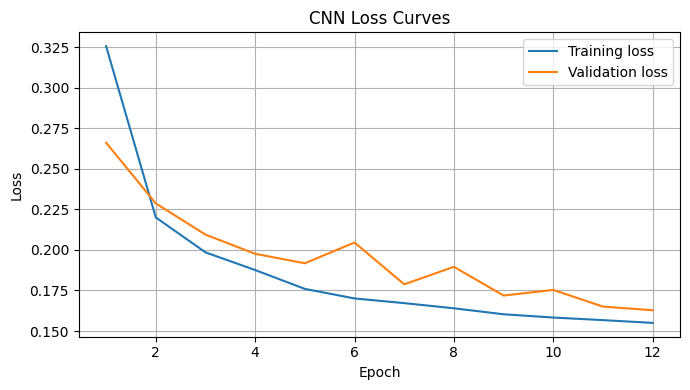

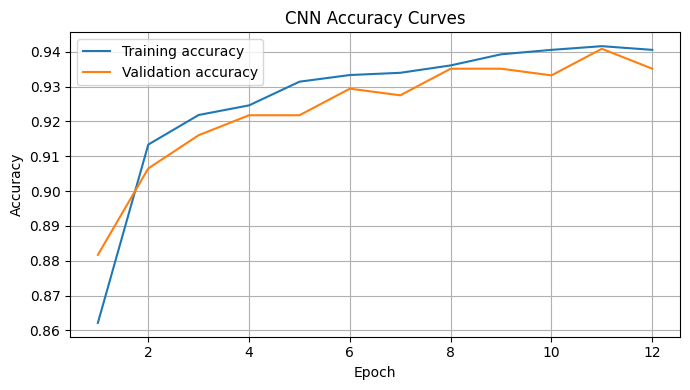

On the VALIDATION SET.
Model average loss: 0.163       Model accuracy: 93.511%

              precision    recall  f1-score   support

           0     0.8855    0.8593    0.8722       135
           1     0.9517    0.9614    0.9565       389

    accuracy                         0.9351       524
   macro avg     0.9186    0.9103    0.9144       524
weighted avg     0.9346    0.9351    0.9348       524



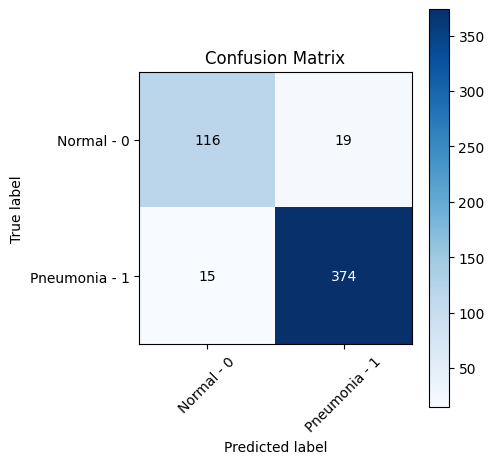

On the TEST SET.
Model average loss: 0.426       Model accuracy: 82.853%

              precision    recall  f1-score   support

           0     0.9205    0.5940    0.7221       234
           1     0.7992    0.9692    0.8760       390

    accuracy                         0.8285       624
   macro avg     0.8598    0.7816    0.7990       624
weighted avg     0.8447    0.8285    0.8183       624



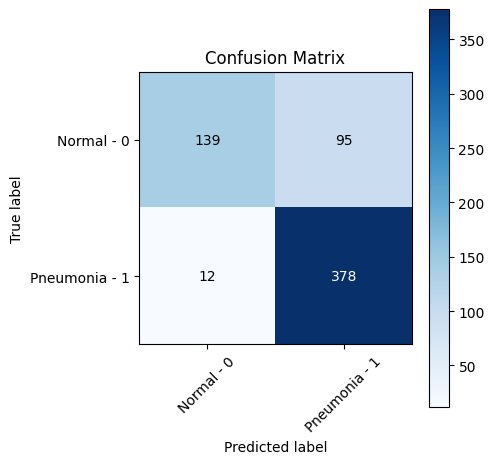

In [8]:
#Classifier Head 1.
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

model_name = "deit_tiny_patch16_224"

model_clh = timm.create_model(model_name , pretrained = True)

model_clh.reset_classifier(num_classes = 2)

for p in model_clh.parameters():
    p.requires_grad = False

for p in model_clh.head.parameters():
    p.requires_grad = True

model_clh = model_clh.cpu()

trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

model_clh_1 , best_state_clh_1 , results_clh_1 = Train_Classifier(
    model = model_clh ,
    initial_lr = 1e-3 ,
    weight_decay = 0 ,
    num_epochs = 12 ,
    training_dataloader = training_dataloader,
    validation_dataloader = validation_dataloader ,
    use_scheduler = True
)

torch.save(results_clh_1 , "results_clh_1.pt")
torch.save(best_state_clh_1 , "best_state_clh_1.pt")

Plot_Classifier_Curves(results_clh_1)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_1 , dataloader = validation_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_1 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

386 5524802
Epoch 01 | Train loss: 0.3258, acc: 0.8621 | Val loss: 0.2662, acc: 0.8817
Epoch 02 | Train loss: 0.2201, acc: 0.9133 | Val loss: 0.2288, acc: 0.9065
Epoch 03 | Train loss: 0.1986, acc: 0.9218 | Val loss: 0.2096, acc: 0.9160
Epoch 04 | Train loss: 0.1877, acc: 0.9248 | Val loss: 0.1977, acc: 0.9237
Epoch 05 | Train loss: 0.1761, acc: 0.9314 | Val loss: 0.1919, acc: 0.9237
Epoch 06 | Train loss: 0.1702, acc: 0.9331 | Val loss: 0.2048, acc: 0.9294
Epoch 07 | Train loss: 0.1674, acc: 0.9337 | Val loss: 0.1790, acc: 0.9275
Epoch 08 | Train loss: 0.1642, acc: 0.9361 | Val loss: 0.1898, acc: 0.9351
Epoch 09 | Train loss: 0.1606, acc: 0.9393 | Val loss: 0.1721, acc: 0.9351
Epoch 10 | Train loss: 0.1586, acc: 0.9405 | Val loss: 0.1756, acc: 0.9313
Epoch 11 | Train loss: 0.1570, acc: 0.9416 | Val loss: 0.1654, acc: 0.9408
Epoch 12 | Train loss: 0.1553, acc: 0.9405 | Val loss: 0.1631, acc: 0.9332
Training time (minutes): 13.77
Best epoch:  12 with loss  0.16313 and accuracy  93.32 %.

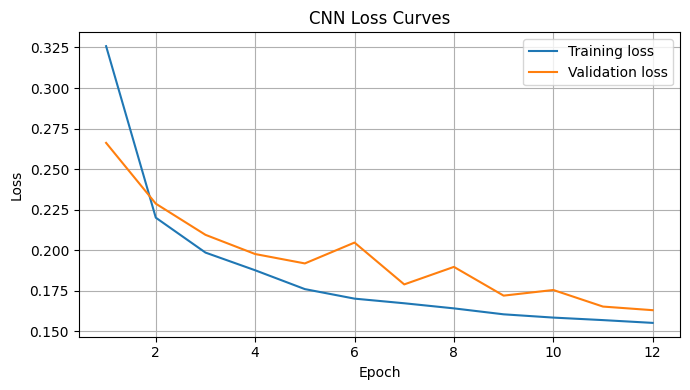

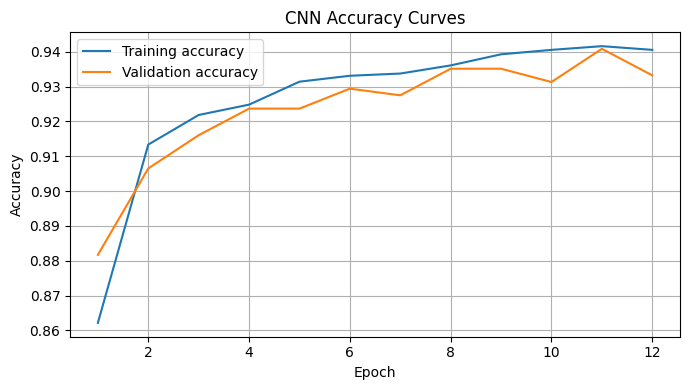

On the VALIDATION SET.
Model average loss: 0.163       Model accuracy: 93.321%

              precision    recall  f1-score   support

           0     0.8788    0.8593    0.8689       135
           1     0.9515    0.9589    0.9552       389

    accuracy                         0.9332       524
   macro avg     0.9152    0.9091    0.9120       524
weighted avg     0.9328    0.9332    0.9330       524



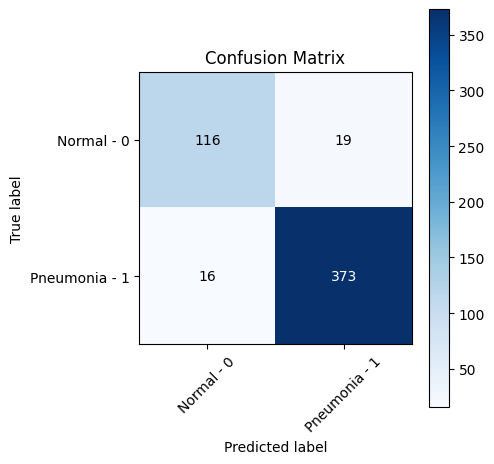

On the TEST SET.
Model average loss: 0.425       Model accuracy: 82.853%

              precision    recall  f1-score   support

           0     0.9205    0.5940    0.7221       234
           1     0.7992    0.9692    0.8760       390

    accuracy                         0.8285       624
   macro avg     0.8598    0.7816    0.7990       624
weighted avg     0.8447    0.8285    0.8183       624



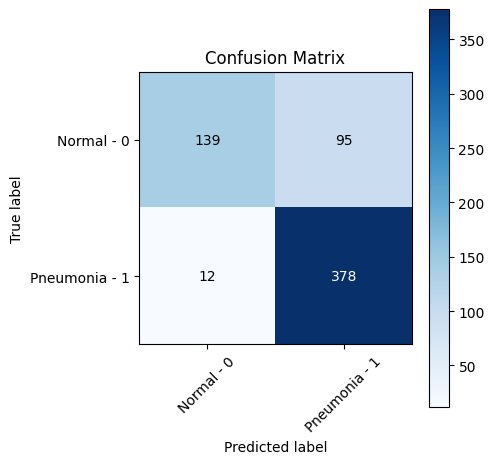

In [9]:
#Classifier Head 2.
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

model_name = "deit_tiny_patch16_224"

model_clh = timm.create_model(model_name , pretrained = True)

model_clh.reset_classifier(num_classes = 2)

for p in model_clh.parameters():
    p.requires_grad = False

for p in model_clh.head.parameters():
    p.requires_grad = True

model_clh = model_clh.cpu()

trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

model_clh_2 , best_state_clh_2 , results_clh_2 = Train_Classifier(
    model = model_clh ,
    initial_lr = 1e-3 ,
    weight_decay = 1e-3 ,
    num_epochs = 12 ,
    training_dataloader = training_dataloader,
    validation_dataloader = validation_dataloader ,
    use_scheduler = True
)

torch.save(results_clh_2 , "results_clh_2.pt")
torch.save(best_state_clh_2 , "best_state_clh_2.pt")

Plot_Classifier_Curves(results_clh_2)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_2 , dataloader = validation_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_2 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

tensor([1.9390, 0.6737])
386 5524802
Epoch 01 | Train loss: 0.3507, acc: 0.8479 | Val loss: 0.3028, acc: 0.8817
Epoch 02 | Train loss: 0.2456, acc: 0.9012 | Val loss: 0.2663, acc: 0.8989
Epoch 03 | Train loss: 0.2219, acc: 0.9133 | Val loss: 0.2480, acc: 0.9122
Epoch 04 | Train loss: 0.2105, acc: 0.9161 | Val loss: 0.2360, acc: 0.9103
Epoch 05 | Train loss: 0.1988, acc: 0.9214 | Val loss: 0.2309, acc: 0.9237
Epoch 06 | Train loss: 0.1919, acc: 0.9240 | Val loss: 0.2382, acc: 0.9256
Epoch 07 | Train loss: 0.1871, acc: 0.9284 | Val loss: 0.2170, acc: 0.9198
Epoch 08 | Train loss: 0.1846, acc: 0.9278 | Val loss: 0.2260, acc: 0.8950
Epoch 09 | Train loss: 0.1813, acc: 0.9267 | Val loss: 0.2151, acc: 0.9294
Epoch 10 | Train loss: 0.1784, acc: 0.9280 | Val loss: 0.2131, acc: 0.9046
Epoch 11 | Train loss: 0.1755, acc: 0.9327 | Val loss: 0.2020, acc: 0.9332
Epoch 12 | Train loss: 0.1743, acc: 0.9316 | Val loss: 0.1999, acc: 0.9313
Training time (minutes): 13.76
Best epoch:  12 with loss  0.199

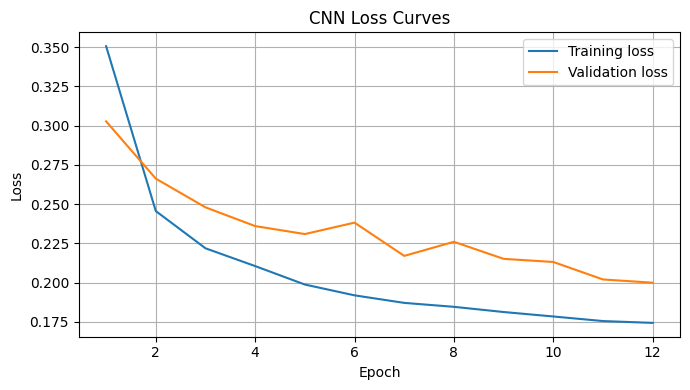

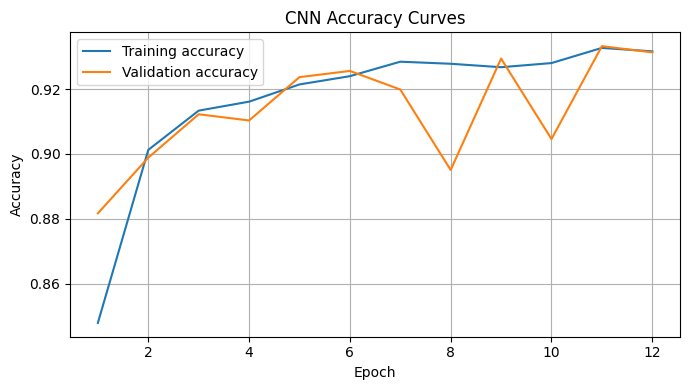

On the VALIDATION SET.
Model average loss: 0.191       Model accuracy: 93.130%

              precision    recall  f1-score   support

           0     0.8194    0.9407    0.8759       135
           1     0.9783    0.9280    0.9525       389

    accuracy                         0.9313       524
   macro avg     0.8988    0.9344    0.9142       524
weighted avg     0.9374    0.9313    0.9328       524



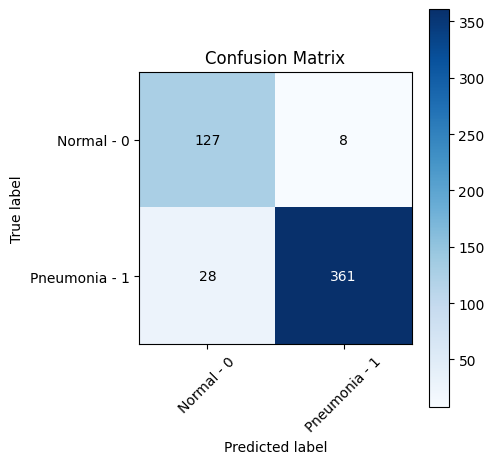

On the TEST SET.
Model average loss: 0.339       Model accuracy: 85.096%

              precision    recall  f1-score   support

           0     0.8811    0.6966    0.7780       234
           1     0.8383    0.9436    0.8878       390

    accuracy                         0.8510       624
   macro avg     0.8597    0.8201    0.8329       624
weighted avg     0.8543    0.8510    0.8467       624



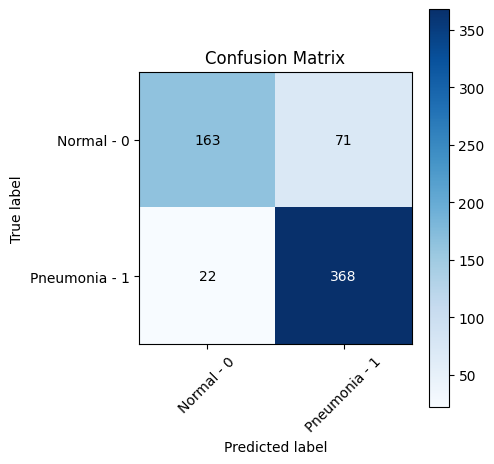

In [10]:
#Classifier Head 3.
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

#Calculation weights according to formula described in the report.
counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

model_name = "deit_tiny_patch16_224"

model_clh = timm.create_model(model_name , pretrained = True)

model_clh.reset_classifier(num_classes = 2)

for p in model_clh.parameters():
    p.requires_grad = False

for p in model_clh.head.parameters():
    p.requires_grad = True

model_clh = model_clh.cpu()

trainable_parameters = sum(p.numel() for p in model_clh.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_clh.parameters())
print(trainable_parameters , total_parameters)

model_clh_3 , best_state_clh_3 , results_clh_3 = Train_Classifier(
    model = model_clh ,
    initial_lr = 1e-3 ,
    weight_decay = 1e-3 ,
    num_epochs = 12 ,
    training_dataloader = training_dataloader,
    validation_dataloader = validation_dataloader ,
    use_scheduler = True , 
    weight = weight
)

torch.save(results_clh_3 , "results_clh_3.pt")
torch.save(best_state_clh_3 , "best_state_clh_3.pt")

Plot_Classifier_Curves(results_clh_3)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_3 , dataloader = validation_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_clh_3 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

##### Δημιουργούμε νέους dataloaders με το κατάλληλο batch size.

In [11]:
batch_size = 16
training_dataloader_16 = DataLoader(training_dataset , batch_size = batch_size , shuffle = True , num_workers = 0)
validation_dataloader_16   = DataLoader(validation_dataset , batch_size = batch_size , shuffle = False , num_workers = 0)

test_dataset = PneumoniaMNIST(split = "test" , download = True, root = root , transform = transform)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False , num_workers = 0)

images , labels = next(iter(training_dataloader_16))
print(images.shape)
print(labels.shape, labels.dtype)

print(len(training_dataset) , len(validation_dataset) , len(test_dataset)) 
print(training_dataset.split, validation_dataset.split , test_dataset.split) 

torch.Size([16, 3, 224, 224])
torch.Size([16, 1]) torch.int32
4708 524 624
train val test


##### Για τον feature extractor, κάνουμε unfreeze τα δύο τελευταία blocks.

tensor([1.9390, 0.6737])
890114 5524802
Epoch 01 | Train loss: 0.2141, acc: 0.9119 | Val loss: 0.1744, acc: 0.9294
Epoch 02 | Train loss: 0.1406, acc: 0.9486 | Val loss: 0.1376, acc: 0.9485
Epoch 03 | Train loss: 0.1019, acc: 0.9592 | Val loss: 0.1454, acc: 0.9370
Epoch 04 | Train loss: 0.0827, acc: 0.9688 | Val loss: 0.1186, acc: 0.9542
Epoch 05 | Train loss: 0.0594, acc: 0.9758 | Val loss: 0.1618, acc: 0.9523
Epoch 06 | Train loss: 0.0339, acc: 0.9879 | Val loss: 0.1345, acc: 0.9580
Epoch 07 | Train loss: 0.0201, acc: 0.9938 | Val loss: 0.1390, acc: 0.9580
Epoch 08 | Train loss: 0.0065, acc: 0.9992 | Val loss: 0.1862, acc: 0.9580
Epoch 09 | Train loss: 0.0013, acc: 1.0000 | Val loss: 0.1980, acc: 0.9542
Epoch 10 | Train loss: 0.0006, acc: 1.0000 | Val loss: 0.2061, acc: 0.9542
Training time (minutes): 14.39
Best epoch:  4 with loss  0.11858 and accuracy  95.42 %.
Best validation accuracy:  95.8 % at epoch  6 .


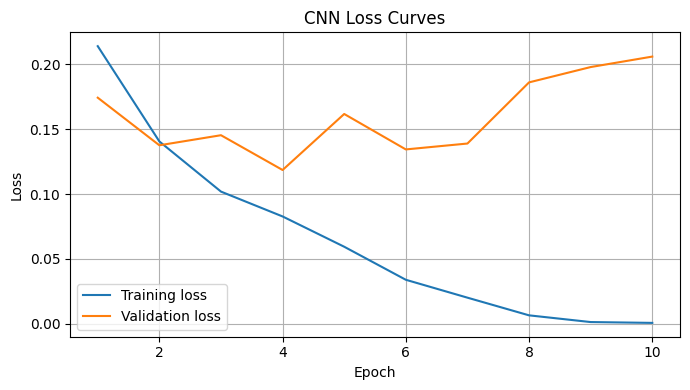

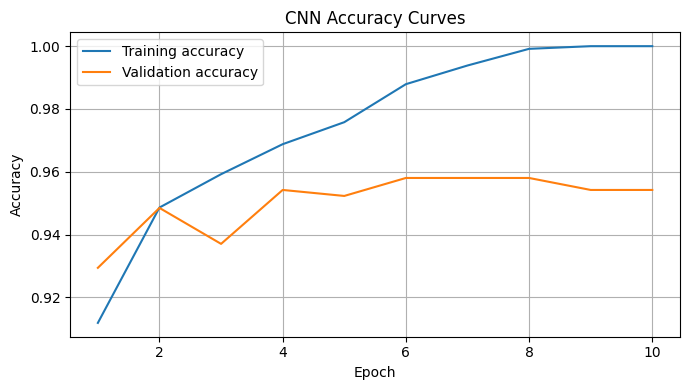

On the VALIDATION SET.
Model average loss: 0.119       Model accuracy: 95.420%

              precision    recall  f1-score   support

           0     0.9111    0.9111    0.9111       135
           1     0.9692    0.9692    0.9692       389

    accuracy                         0.9542       524
   macro avg     0.9401    0.9401    0.9401       524
weighted avg     0.9542    0.9542    0.9542       524



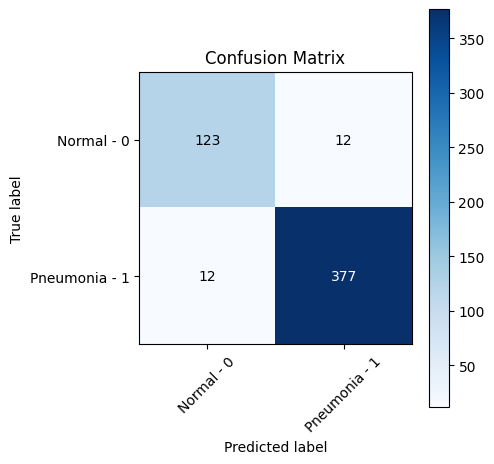

On the TEST SET.
Model average loss: 0.492       Model accuracy: 87.019%

              precision    recall  f1-score   support

           0     0.9474    0.6923    0.8000       234
           1     0.8411    0.9769    0.9039       390

    accuracy                         0.8702       624
   macro avg     0.8942    0.8346    0.8520       624
weighted avg     0.8809    0.8702    0.8649       624



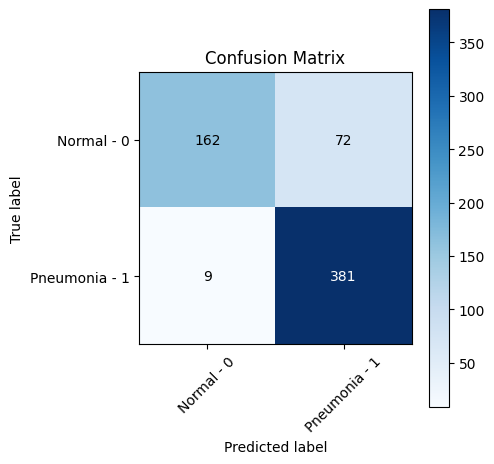

In [12]:
#Feature Extractor 1.

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

model_name = "deit_tiny_patch16_224"
model_fe = timm.create_model(model_name , pretrained = True)

model_fe.reset_classifier(num_classes = 2)

for p in model_fe.parameters():
    p.requires_grad = False
#Unfreeze last two blocks only.
for name, p in model_fe.named_parameters():
    if name.startswith("blocks.10") or name.startswith("blocks.11") or name.startswith("head"):
        p.requires_grad = True

model_fe = model_fe.cpu()

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_1 , best_state_fe_1 , results_fe_1 = Train_Classifier(
    model = model_fe ,
    initial_lr = 1e-4 ,
    weight_decay = 0 ,
    num_epochs = 10 ,
    training_dataloader = training_dataloader_16,
    validation_dataloader = validation_dataloader_16 ,
    use_scheduler = True ,
    weight = None
)

torch.save(results_fe_1 , "results_fe_1.pt")
torch.save(best_state_fe_1 , "best_state_fe_1.pt")

Plot_Classifier_Curves(results_fe_1)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_1 , dataloader = validation_dataloader_16)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_1 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)


tensor([1.9390, 0.6737])
890114 5524802
Epoch 01 | Train loss: 0.2150, acc: 0.9119 | Val loss: 0.1734, acc: 0.9313
Epoch 02 | Train loss: 0.1440, acc: 0.9475 | Val loss: 0.1398, acc: 0.9485
Epoch 03 | Train loss: 0.1079, acc: 0.9569 | Val loss: 0.1481, acc: 0.9351
Epoch 04 | Train loss: 0.0932, acc: 0.9639 | Val loss: 0.1199, acc: 0.9580
Epoch 05 | Train loss: 0.0745, acc: 0.9724 | Val loss: 0.1728, acc: 0.9466
Epoch 06 | Train loss: 0.0547, acc: 0.9792 | Val loss: 0.1267, acc: 0.9580
Epoch 07 | Train loss: 0.0433, acc: 0.9843 | Val loss: 0.1215, acc: 0.9561
Epoch 08 | Train loss: 0.0189, acc: 0.9947 | Val loss: 0.1417, acc: 0.9542
Epoch 09 | Train loss: 0.0087, acc: 0.9981 | Val loss: 0.1728, acc: 0.9561
Epoch 10 | Train loss: 0.0097, acc: 0.9968 | Val loss: 0.1853, acc: 0.9485
Training time (minutes): 14.43
Best epoch:  4 with loss  0.11988 and accuracy  95.8 %.
Best validation accuracy:  95.8 % at epoch  4 .


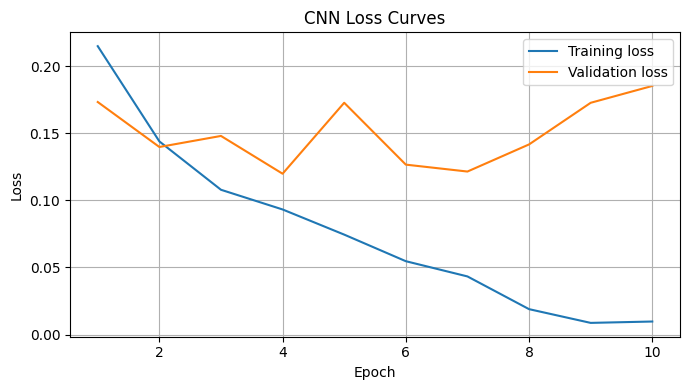

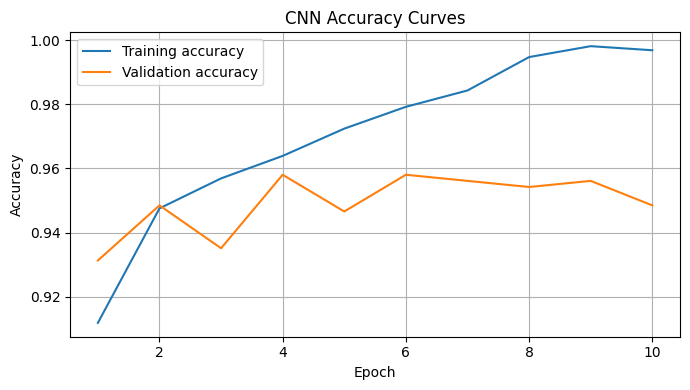

On the VALIDATION SET.
Model average loss: 0.120       Model accuracy: 95.802%

              precision    recall  f1-score   support

           0     0.9248    0.9111    0.9179       135
           1     0.9693    0.9743    0.9718       389

    accuracy                         0.9580       524
   macro avg     0.9471    0.9427    0.9449       524
weighted avg     0.9578    0.9580    0.9579       524



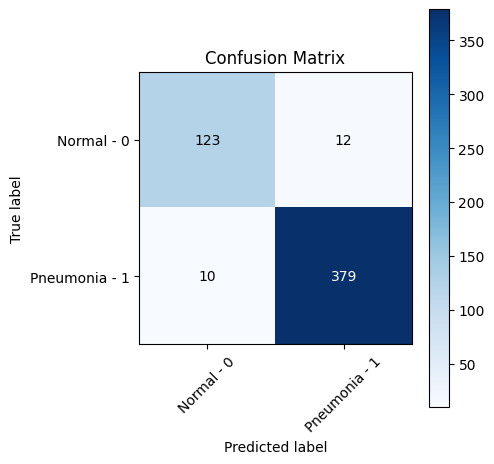

On the TEST SET.
Model average loss: 0.507       Model accuracy: 86.058%

              precision    recall  f1-score   support

           0     0.9509    0.6624    0.7809       234
           1     0.8286    0.9795    0.8978       390

    accuracy                         0.8606       624
   macro avg     0.8898    0.8209    0.8393       624
weighted avg     0.8745    0.8606    0.8539       624



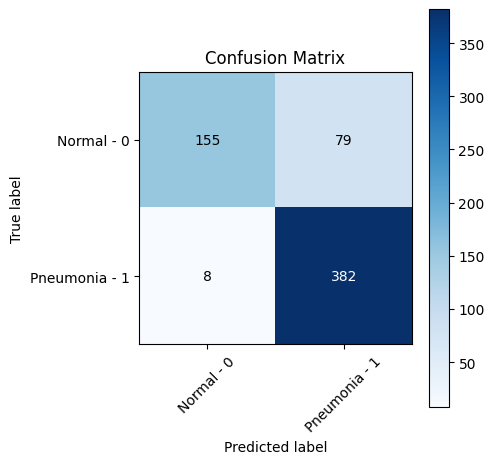

In [13]:
#Feature Extractor 2.

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

model_name = "deit_tiny_patch16_224"
model_fe = timm.create_model(model_name , pretrained = True)

model_fe.reset_classifier(num_classes = 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("blocks.10") or name.startswith("blocks.11") or name.startswith("head"):
        p.requires_grad = True

model_fe = model_fe.cpu()

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_2 , best_state_fe_2 , results_fe_2 = Train_Classifier(
    model = model_fe ,
    initial_lr = 1e-4 ,
    weight_decay = 1e-3 ,
    num_epochs = 10 ,
    training_dataloader = training_dataloader_16,
    validation_dataloader = validation_dataloader_16 ,
    use_scheduler = True ,
    weight = None
)

torch.save(results_fe_2 , "results_fe_2.pt")
torch.save(best_state_fe_2 , "best_state_fe_2.pt")

Plot_Classifier_Curves(results_fe_2)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_2 , dataloader = validation_dataloader_16)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_2 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)


tensor([1.9390, 0.6737])
890114 5524802
Epoch 01 | Train loss: 0.2385, acc: 0.9012 | Val loss: 0.2220, acc: 0.9351
Epoch 02 | Train loss: 0.1649, acc: 0.9359 | Val loss: 0.1660, acc: 0.9351
Epoch 03 | Train loss: 0.1235, acc: 0.9465 | Val loss: 0.1651, acc: 0.9218
Epoch 04 | Train loss: 0.1052, acc: 0.9588 | Val loss: 0.1585, acc: 0.9466
Epoch 05 | Train loss: 0.0859, acc: 0.9656 | Val loss: 0.2500, acc: 0.9542
Epoch 06 | Train loss: 0.0661, acc: 0.9730 | Val loss: 0.2059, acc: 0.9561
Epoch 07 | Train loss: 0.0516, acc: 0.9802 | Val loss: 0.1311, acc: 0.9618
Epoch 08 | Train loss: 0.0375, acc: 0.9847 | Val loss: 0.3461, acc: 0.9466
Epoch 09 | Train loss: 0.0313, acc: 0.9873 | Val loss: 0.2105, acc: 0.9637
Epoch 10 | Train loss: 0.0400, acc: 0.9836 | Val loss: 0.1242, acc: 0.9637
Training time (minutes): 14.42
Best epoch:  10 with loss  0.12422 and accuracy  96.37 %.
Best validation accuracy:  96.37 % at epoch  9 .


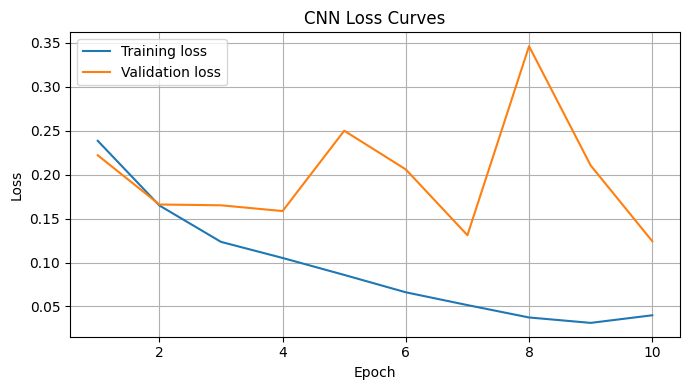

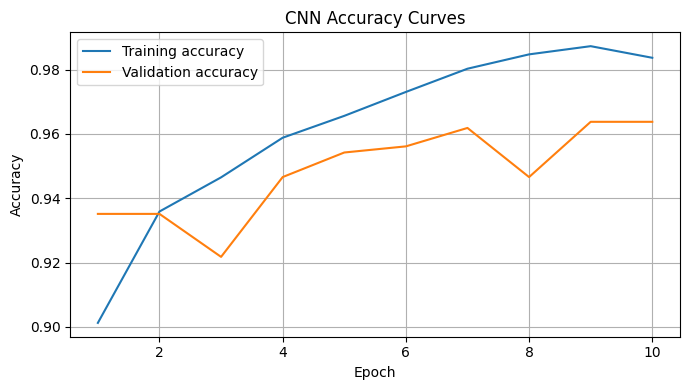

On the VALIDATION SET.
Model average loss: 0.148       Model accuracy: 96.374%

              precision    recall  f1-score   support

           0     0.9028    0.9630    0.9319       135
           1     0.9868    0.9640    0.9753       389

    accuracy                         0.9637       524
   macro avg     0.9448    0.9635    0.9536       524
weighted avg     0.9652    0.9637    0.9641       524



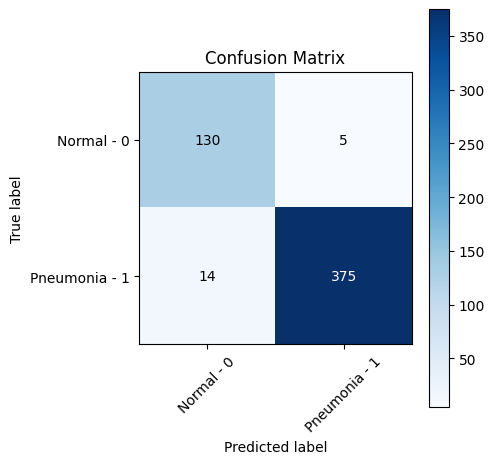

On the TEST SET.
Model average loss: 0.475       Model accuracy: 88.782%

              precision    recall  f1-score   support

           0     0.9020    0.7863    0.8402       234
           1     0.8810    0.9487    0.9136       390

    accuracy                         0.8878       624
   macro avg     0.8915    0.8675    0.8769       624
weighted avg     0.8888    0.8878    0.8861       624



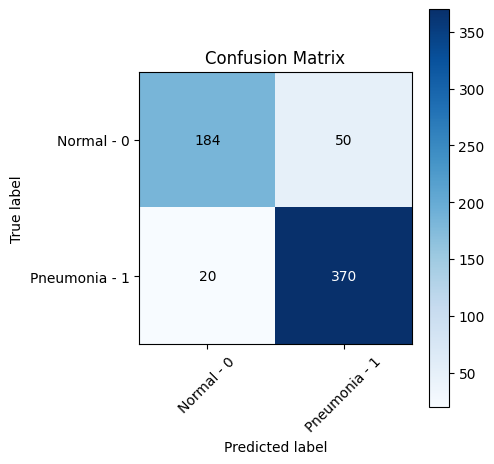

In [14]:
#Feature Extractor 3.

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

model_name = "deit_tiny_patch16_224"
model_fe = timm.create_model(model_name , pretrained = True)

model_fe.reset_classifier(num_classes = 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("blocks.10") or name.startswith("blocks.11") or name.startswith("head"):
        p.requires_grad = True

model_fe = model_fe.cpu()

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_3 , best_state_fe_3 , results_fe_3 = Train_Classifier(
    model = model_fe ,
    initial_lr = 1e-4 ,
    weight_decay = 1e-3 ,
    num_epochs = 10 ,
    training_dataloader = training_dataloader_16,
    validation_dataloader = validation_dataloader_16 ,
    use_scheduler = True ,
    weight = weight
)

torch.save(results_fe_3 , "results_fe_3.pt")
torch.save(best_state_fe_3 , "best_state_fe_3.pt")

Plot_Classifier_Curves(results_fe_3)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_3 , dataloader = validation_dataloader_16)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_3 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)


tensor([1.9390, 0.6737])
890114 5524802
Epoch 01 | Train loss: 0.3174, acc: 0.8607 | Val loss: 0.2849, acc: 0.8397
Epoch 02 | Train loss: 0.2005, acc: 0.9150 | Val loss: 0.2817, acc: 0.8397
Epoch 03 | Train loss: 0.1779, acc: 0.9284 | Val loss: 0.1629, acc: 0.9256
Epoch 04 | Train loss: 0.1638, acc: 0.9348 | Val loss: 0.1810, acc: 0.9065
Epoch 05 | Train loss: 0.1547, acc: 0.9367 | Val loss: 0.1497, acc: 0.9275
Epoch 06 | Train loss: 0.1412, acc: 0.9448 | Val loss: 0.1501, acc: 0.9389
Epoch 07 | Train loss: 0.1414, acc: 0.9429 | Val loss: 0.1708, acc: 0.9198
Epoch 08 | Train loss: 0.1318, acc: 0.9484 | Val loss: 0.1297, acc: 0.9447
Epoch 09 | Train loss: 0.1300, acc: 0.9497 | Val loss: 0.1258, acc: 0.9504
Epoch 10 | Train loss: 0.1236, acc: 0.9503 | Val loss: 0.1325, acc: 0.9332
Training time (minutes): 14.67
Best epoch:  9 with loss  0.12583 and accuracy  95.04 %.
Best validation accuracy:  95.04 % at epoch  9 .


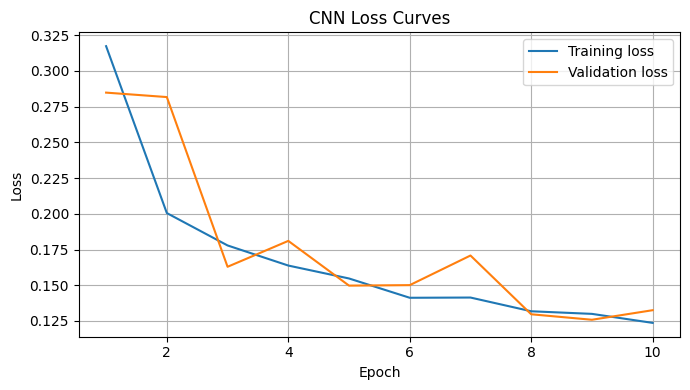

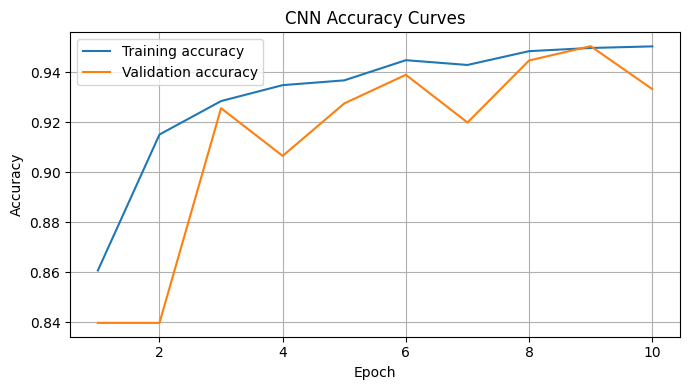

On the VALIDATION SET.
Model average loss: 0.142       Model accuracy: 95.038%

              precision    recall  f1-score   support

           0     0.8516    0.9778    0.9103       135
           1     0.9919    0.9409    0.9657       389

    accuracy                         0.9504       524
   macro avg     0.9217    0.9593    0.9380       524
weighted avg     0.9557    0.9504    0.9514       524



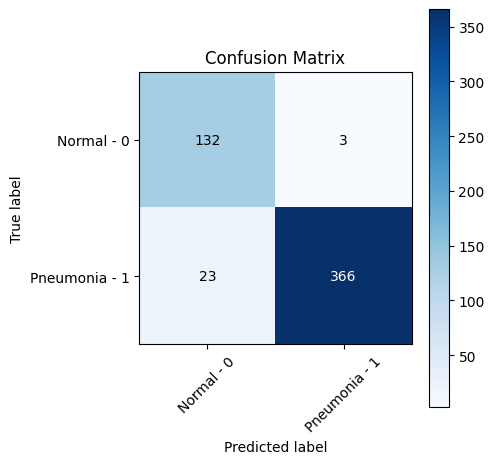

On the TEST SET.
Model average loss: 0.262       Model accuracy: 88.782%

              precision    recall  f1-score   support

           0     0.8796    0.8120    0.8444       234
           1     0.8922    0.9333    0.9123       390

    accuracy                         0.8878       624
   macro avg     0.8859    0.8726    0.8784       624
weighted avg     0.8875    0.8878    0.8868       624



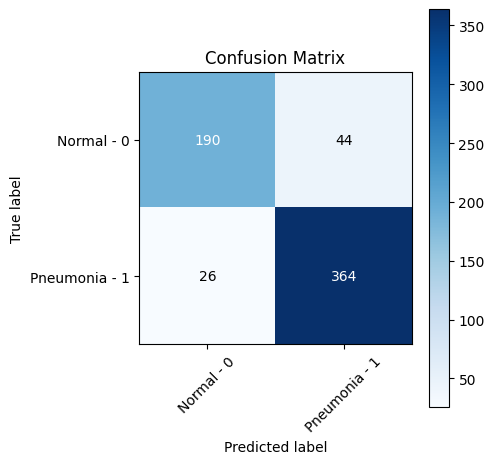

In [15]:
#Feature Extractor 4.

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
rnd.seed(seed)

counts = torch.tensor([1214, 3494], dtype=torch.float)
weight = counts.sum() / (2.0 * counts)
print(weight)

transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224 , scale = (0.9 , 1.0) , ratio = (0.95 , 1.05)) ,
    transforms.RandomRotation(10) ,
    transforms.ToTensor() ,
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)) ,
    transforms.Normalize(mean = [0.485 , 0.456 , 0.406], std = [0.229 , 0.224 , 0.225]) ,
])

training_dataset_aug = PneumoniaMNIST(split="train" , download = True , root = root , transform = transform_aug)

batch_size = 16
training_dataloader_16_aug = DataLoader(training_dataset_aug , batch_size = batch_size , shuffle = True , num_workers = 0)

model_name = "deit_tiny_patch16_224"
model_fe = timm.create_model(model_name , pretrained = True)

model_fe.reset_classifier(num_classes = 2)

for p in model_fe.parameters():
    p.requires_grad = False

for name, p in model_fe.named_parameters():
    if name.startswith("blocks.10") or name.startswith("blocks.11") or name.startswith("head"):
        p.requires_grad = True

model_fe = model_fe.cpu()

trainable_parameters = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model_fe.parameters())
print(trainable_parameters , total_parameters)

model_fe_4 , best_state_fe_4 , results_fe_4 = Train_Classifier(
    model = model_fe ,
    initial_lr = 1e-4 ,
    weight_decay = 1e-3 ,
    num_epochs = 10 ,
    training_dataloader = training_dataloader_16_aug,
    validation_dataloader = validation_dataloader_16 ,
    use_scheduler = True ,
    weight = weight
)

torch.save(results_fe_4 , "results_fe_4.pt")
torch.save(best_state_fe_4 , "best_state_fe_4.pt")

Plot_Classifier_Curves(results_fe_4)

print("On the VALIDATION SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_4 , dataloader = validation_dataloader_16)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)

print("On the TEST SET.")
cm , report , loss , accuracy = Test_Classifier(model = model_fe_4 , dataloader = test_dataloader)
print(f"Model average loss: {loss:.3f}       Model accuracy: {accuracy*100:.3f}%\n")
print(report)
Plot_CM(cm)
